# Comparación de Métodos Tabulares de Control en RL

## 1. Marco Teórico

Este notebook implementa y compara distintos algoritmos de control en Aprendizaje por Refuerzo dentro de un entorno tabular (`Taxi-v3`).

El problema se modela como un **Proceso de Decisión de Markov (MDP)** definido por:

- Conjunto de estados \( S \)
- Conjunto de acciones \( A \)
- Dinámica de transición \( P(s', r | s, a) \)
- Factor de descuento \( \gamma \)

Según la formulación clásica de MDP (ver Proceso de Decisión de Markov), el objetivo es encontrar una política óptima \( \pi^* \) que maximice el retorno esperado.

En este notebook se comparan métodos de control sin modelo, es decir, que no conocen la dinámica del entorno y aprenden únicamente a partir de la experiencia.

In [1]:
from src.agents import AgentMonteCarloOnPolicy, AgentMonteCarloOffPolicy, AgentSARSA, AgentQLearning
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

seed = 200

# Fijamos la semilla para reproducibilidad
seed = 42
np.random.seed(seed)
np.random.default_rng(seed)

# Fijamos la semilla en Gymnasium
def make_env(env_name):
    env = gym.make(env_name, render_mode='None')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

n_episodes = 50000

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_success_ratio(final_results):
    plt.figure(figsize=(8, 4))
    
    # Iteramos sobre cada agente guardado en el diccionario
    for name, data in final_results.items():
        successes = np.array(data["list_stats_success"])
        cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)
        # Dibujamos la línea de este agente y le asignamos su nombre para la leyenda
        plt.plot(cumulative_ratio, label=name)

    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.legend() # <-- Muy importante para distinguir los colores
    plt.show()

def plot_episode_length(final_results):
    plt.figure(figsize=(10, 5))
    
    for name, data in final_results.items():
        y = np.array(data["episode_lengths"], dtype=float)
        x = np.arange(len(y))
        
        # Añadimos alpha=0.6 para dar cierta transparencia. 
        # Como los pasos (steps) oscilan mucho, si las líneas son opacas no se verá nada debajo.
        plt.plot(x, y, label=name, alpha=0.6)

    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_global_avg(final_results):
    plt.figure(figsize=(8, 4))
    
    for name, data in final_results.items():
        list_stats = data["list_stats"]
        indices = list(range(len(list_stats)))
        plt.plot(indices, list_stats, label=name)

    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.legend()
    plt.show()

# Opcional: Una función "wrapper" para llamar a las tres de golpe
def plot_all_results(final_results):
    plot_success_ratio(final_results)
    plot_episode_length(final_results)
    plot_global_avg(final_results)

# 2. Métodos Implementados

Se comparan cuatro enfoques de control:



## Monte Carlo On-Policy

Basado en los métodos descritos en *Métodos de Monte Carlo*.

- Aprende a partir del retorno completo del episodio.
- No utiliza bootstrapping.
- Solo puede actualizar tras finalizar el episodio.
- Alta varianza.

Actualización típica:

($
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha (G_t - Q(S_t, A_t))
$)
donde ($ G_t $) es el retorno acumulado.



## Monte Carlo Off-Policy

Permite aprender una política objetivo distinta de la política de comportamiento.
Se basa en muestreo por importancia.

Esto permite separar:

- Política exploratoria
- Política óptima



## SARSA (TD On-Policy)

Basado en *Métodos de Diferencias Temporales*.

- Aprende paso a paso.
- Utiliza bootstrapping.
- Es on-policy.

Actualización:

($
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]
$)



## Q-Learning (TD Off-Policy)

También basado en TD.

- Aprende política óptima directamente.
- Off-policy.
- Utiliza el máximo sobre acciones futuras.

Actualización:

($
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)]
$)

Este método aproxima la Iteración de Valor sin conocer el modelo del entorno.

# 3. Monte Carlo vs Diferencias Temporales

Siguiendo la comparación vista en *Métodos de n-Pasos*:

| Característica | Monte Carlo | TD |
|---------------|------------|----|
| Requiere episodio completo | Sí | No |
| Bootstrapping | No | Sí |
| Varianza | Alta | Menor |
| Sesgo | Bajo | Mayor |
| Aplicable a tareas no episódicas | No | Sí |

Monte Carlo se encuentra en un extremo del espectro, mientras que TD(0) se encuentra en el otro.  
Q-Learning y SARSA pueden interpretarse como métodos TD de un paso.

In [3]:
# 2. Instanciamos nuestros agentes y entornos
envMonteCarloOnPolicy = make_env("Taxi-v3")
envMonteCarloOffPolicy = make_env("Taxi-v3")
envSARSA = make_env("Taxi-v3")
envQLearning = make_env("Taxi-v3")

agentMonteCarloOnPolicy = AgentMonteCarloOnPolicy(envMonteCarloOnPolicy)
agentMonteCarloOffPolicy = AgentMonteCarloOffPolicy(envMonteCarloOffPolicy)
agentSARSA = AgentSARSA(envSARSA)
agentQLearning = AgentQLearning(envQLearning)

step_display = n_episodes // 10  # Usamos // para asegurar que sea un entero

# Agrupamos todo en una lista para iterar cómodamente sin repetir código
agents_and_envs = [
    ("MC On-Policy", agentMonteCarloOnPolicy, envMonteCarloOnPolicy),
    ("MC Off-Policy", agentMonteCarloOffPolicy, envMonteCarloOffPolicy),
    ("SARSA", agentSARSA, envSARSA),
    ("Q-Learning", agentQLearning, envQLearning)
]

# Diccionario para guardar las estadísticas de todos los agentes sin sobrescribirlas
final_results = {}

# 3. Bucle de entrenamiento
for episode in tqdm(range(n_episodes)):
    
    # Entrenamos a cada agente un episodio completo en su respectivo entorno
    for name, agent, env in agents_and_envs:
        state, info = env.reset(seed=seed)
        done = False
        
        # Jugamos un episodio completo para el agente actual
        while not done:
            # El agente decide la acción
            action = agent.get_action(state)
            
            # El entorno reacciona
            next_state, reward, terminated, truncated, info = env.step(action)
            
            # Actualizamos el agente
            # Nota: Asumo que todos tus agentes comparten esta misma firma en el método update()
            agent.update(state, action, next_state, reward, terminated, truncated, info)
            
            # Comprobamos si el episodio ha terminado y avanzamos el estado
            done = terminated or truncated
            state = next_state
            
        # Mostramos la evolución en el terminal para cada agente
        if episode % step_display == 0 and episode != 0:
            # Ojo: si en tus agentes cambiaste 'stats' por 'stats_sum' como en DQN, modifícalo aquí
            print(f"[{name}] success: {agent.stats / episode:.4f}, epsilon: {agent.epsilon:.4f}")

# 4. Obtenemos los resultados estadísticos finales y cerramos entornos
for name, agent, env in agents_and_envs:
    Q, list_stats, episode_lengths, list_stats_success = agent.get_stats()
    
    # Guardamos los resultados en el diccionario usando el nombre del agente como clave
    final_results[name] = {
        "Q": Q,
        "list_stats": list_stats,
        "episode_lengths": episode_lengths,
        "list_stats_success": list_stats_success
    }
    
    # Cerramos el entorno de este agente
    env.close()

c:\Users\David\Universidad\Máster\Asignaturas\Segundo Cuatrimestre\Extensiones de Machine Learning\emlenv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='None' that is not in the possible render_modes (['human', 'ansi', 'rgb_array']).
  logger.warn(
 10%|█         | 5071/50000 [00:32<01:39, 452.98it/s]

[MC On-Policy] success: -224.6432, epsilon: 0.4000
[MC Off-Policy] success: -30.7758, epsilon: 0.1000
[SARSA] success: -104.6270, epsilon: 0.0820
[Q-Learning] success: -77.0384, epsilon: 0.0820


 20%|██        | 10069/50000 [00:43<01:24, 474.01it/s]

[MC On-Policy] success: -128.4466, epsilon: 0.4000
[MC Off-Policy] success: -14.3032, epsilon: 0.1000
[SARSA] success: -49.1207, epsilon: 0.0100
[Q-Learning] success: -35.2945, epsilon: 0.0100


 30%|███       | 15096/50000 [00:53<01:12, 479.70it/s]

...

 80%|████████  | 40053/50000 [01:46<00:21, 471.27it/s]

[MC On-Policy] success: -54.5890, epsilon: 0.4000
[MC Off-Policy] success: -1.7565, epsilon: 0.1000
[SARSA] success: -6.6588, epsilon: 0.0100
[Q-Learning] success: -3.1919, epsilon: 0.0100


 90%|█████████ | 45050/50000 [01:56<00:10, 485.05it/s]

[MC On-Policy] success: -51.6908, epsilon: 0.4000
[MC Off-Policy] success: -1.2745, epsilon: 0.1000
[SARSA] success: -5.0852, epsilon: 0.0100
[Q-Learning] success: -2.0066, epsilon: 0.0100


100%|██████████| 50000/50000 [02:06<00:00, 394.69it/s]


# 4. Métricas de Evaluación

Se analizan tres métricas:


## Ratio de éxito acumulado

Mide la frecuencia con la que el agente completa correctamente la tarea.

Permite observar convergencia y estabilidad.



## Longitud de episodio

Indica eficiencia de la política aprendida.
Menor longitud suele implicar política más cercana a la óptima.



## Retorno medio acumulado

Aproxima el rendimiento esperado de la política:

($
J(\pi) = \mathbb{E}[G_t]
$)

Permite comparar calidad global de aprendizaje.

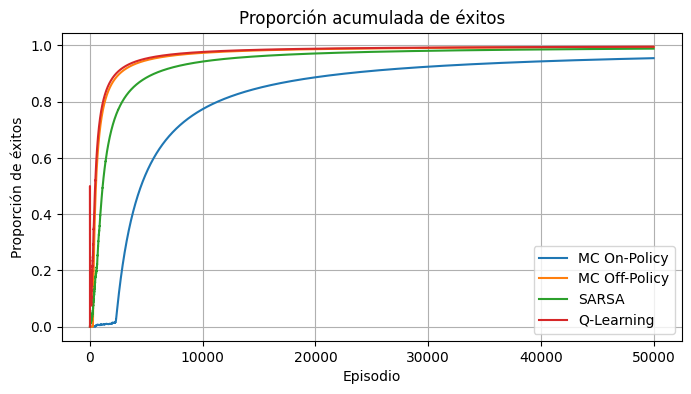

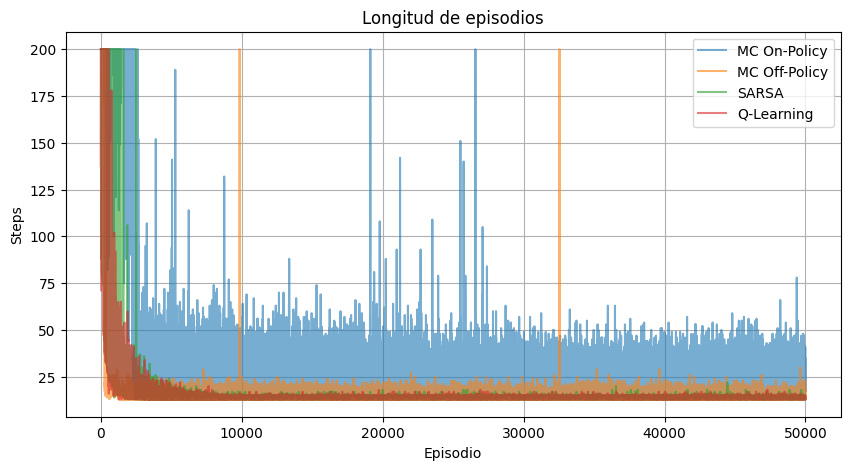

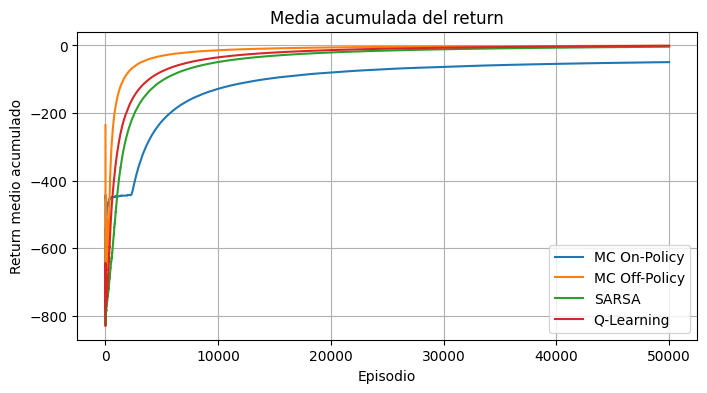

In [4]:
plot_all_results(final_results)

# 5. Conclusiones Teóricas

- Monte Carlo aprende a partir de retornos completos, pero sufre mayor varianza.
- SARSA es más conservador al ser on-policy.
- Q-Learning converge más rápido en muchos entornos tabulares.
- Los métodos TD combinan ideas de Monte Carlo y Programación Dinámica.

Este experimento confirma empíricamente la teoría desarrollada en:

- Procesos de Decisión de Markov
- Programación Dinámica
- Métodos de Monte Carlo
- Métodos de Diferencias Temporales

El entorno Taxi-v3 es completamente tabular, por lo que estos métodos son suficientes.
En entornos de alta dimensión sería necesario utilizar aproximación de funciones.

# 6. Análisis detallado de resultados

En esta sección analizamos el comportamiento empírico de los cuatro algoritmos de control tabular evaluados en `Taxi-v3`:

- **MC On-Policy**
- **MC Off-Policy**
- **SARSA (TD On-Policy)**
- **Q-Learning (TD Off-Policy)**

La comparación se hace en tres dimensiones complementarias:

1. **Proporción acumulada de éxitos** (tasa de resolución del episodio).
2. **Longitud de episodios** (número de pasos).
3. **Media acumulada del return** (recompensa total por episodio, promediada).

Estos tres indicadores están alineados con la teoría de **control en MDPs**, donde buscamos una política que maximice retorno esperado (óptima) y, a la vez, sea eficiente en número de pasos en tareas como Taxi (penalización por movimiento y recompensa por entregar). 


## 6.1 Proporción acumulada de éxitos (convergencia y estabilidad)

En la gráfica de **proporción acumulada de éxitos** se observa un patrón claro:

- **Q-Learning** y **MC Off-Policy** alcanzan muy pronto valores cercanos a **1.0**, estabilizándose rápidamente.
- **SARSA** converge también a una tasa de éxito alta, pero lo hace **más lentamente** que Q-Learning/MC Off-Policy.
- **MC On-Policy** es el que más tarda: su curva sube mucho más despacio y se mantiene por debajo del resto durante gran parte del entrenamiento.

### Interpretación teórica
**Monte Carlo** actualiza al final del episodio y **no hace bootstrapping**, por lo que suele tener **mayor varianza** y necesitar más episodios para estabilizar buenas estimaciones (especialmente si el episodio es largo o si la exploración genera trayectorias poco informativas). 

En cambio, **TD** (SARSA y Q-Learning) combina ideas de Monte Carlo y Programación Dinámica, actualizando **paso a paso** y usando **bootstrapping**, lo que típicamente acelera el aprendizaje del control en tareas tabulares. 
### On-policy vs Off-policy
- **Q-Learning (off-policy)** actualiza con el término \(\max_a Q(s',a)\), empujando de forma directa hacia la política greedy/óptima aunque los datos provengan de una política exploratoria. Eso suele traducirse en **convergencia más rápida** en entornos tabulares.
- **SARSA (on-policy)** incorpora \(Q(s',a')\) (la acción realmente tomada por la política exploratoria), por lo que “aprende lo que hace”, siendo más conservador y, a menudo, algo más lento en aproximarse a la política óptima.
- En **MC Off-Policy**, el uso de una política de comportamiento (exploratoria) distinta de la política objetivo permite mejorar la política objetivo separando exploración y evaluación, lo cual puede acelerar la mejora de política respecto a MC on-policy en algunos casos. 

**Conclusión de esta gráfica:**  
La jerarquía empírica de velocidad de convergencia observada es coherente con la teoría:

\[
\text{Q-Learning} \approx \text{MC Off-Policy} \;>\; \text{SARSA} \;>\; \text{MC On-Policy}
\]



## 6.2 Longitud de episodios (eficiencia y calidad de la política)

En la gráfica de **longitud de episodios** se aprecia que:

- Para **Q-Learning**, **MC Off-Policy** y **SARSA**, tras los primeros episodios, la longitud cae rápidamente a un rango bajo (≈ 12–20 pasos) y se mantiene bastante estable.
- **MC On-Policy** mantiene episodios **considerablemente más largos** durante mucho más tiempo, además de mostrar una dispersión notable y picos altos incluso en fases avanzadas.

### Interpretación
En Taxi, la longitud de episodio es un proxy muy directo de eficiencia: una política buena:

- encuentra al pasajero,
- llega al destino,
- minimiza pasos (evita penalizaciones por movimiento).

Que **Q-Learning y MC Off-Policy** estabilicen longitudes bajas pronto indica que aprenden antes una política cercana a óptima.

En **MC On-Policy**, la combinación de:
- actualización solo al final del episodio,
- alta varianza del retorno,
- dependencia de trayectorias generadas por una política exploratoria,

hace más probable que durante el entrenamiento se sigan generando episodios subóptimos durante más tiempo, lo cual se refleja en una longitud media mayor y en picos (trayectorias malas).

### Relación con TD y bootstrapping
El **bootstrapping** en TD permite propagar información de manera local paso a paso (sin esperar al final del episodio), lo que suele reducir antes las trayectorias “erráticas” y mejora la eficiencia rápidamente.

**Conclusión de esta gráfica:**  
Los métodos basados en TD (especialmente Q-Learning) tienden a producir políticas eficientes antes. MC On-Policy tarda más en “compactar” el comportamiento hacia episodios cortos.


## 6.3 Media acumulada del return (rendimiento global)

La curva de **media acumulada del return** confirma lo anterior:

- **Q-Learning** y **MC Off-Policy** mejoran el return medio con rapidez y se estabilizan cerca de 0 (o valores poco negativos).
- **SARSA** también se aproxima a la zona alta, pero más gradualmente.
- **MC On-Policy** mejora mucho más lento y se queda claramente por debajo durante gran parte del entrenamiento.

### Qué significa un return más alto en Taxi
En Taxi, el return por episodio suele estar dominado por:
- penalizaciones por cada paso (-1 típicamente),
- penalizaciones por acciones incorrectas,
- recompensa positiva al completar.

Por tanto, un return medio más alto significa:
- menos pasos,
- menos errores,
- más episodios completados con éxito.

Esto encaja con la correlación observada entre **episodios más cortos** y **mejor return medio**.

### Conexión con teoría MC vs TD
En el material de TD se explica que TD es una mezcla entre MC y DP:
- aprende de experiencia (como MC),
- pero actualiza usando estimaciones (como DP), es decir, usa bootstrapping. 

En problemas tabulares, esto suele dar una ventaja práctica de aprendizaje, que es exactamente lo que se observa aquí: **curvas de return más rápidas y estables**.

**Conclusión de esta gráfica:**  
El ranking en return medio sigue el mismo patrón que éxito y longitud de episodio, lo cual es buena señal: las métricas son consistentes y reflejan una mejora real de política.



## 6.4 Conclusión global

Los tres gráficos son coherentes entre sí y con la teoría vista en los temas:

- **Q-Learning** es el método que converge más rápido a una política de alta calidad, típico de un método TD **off-policy** que aprende directamente hacia la política greedy. 
- **SARSA** converge a buen rendimiento pero con una mejora más gradual, coherente con su naturaleza **on-policy** (aprende la política exploratoria que ejecuta).
- **MC Off-Policy** mejora notablemente respecto a MC On-Policy y se aproxima al rendimiento de Q-Learning en esta tarea, mostrando cómo separar política objetivo de comportamiento puede ser ventajoso.
- **MC On-Policy** es el más lento y con mayor dispersión en longitud de episodios, consistente con el hecho de que Monte Carlo requiere episodios completos y suele tener mayor varianza. 

En un entorno tabular como `Taxi-v3`, donde la representación exacta de \(Q(s,a)\) es viable, los métodos TD suelen ofrecer una convergencia práctica más rápida que MC, lo cual queda reflejado de forma clara en los resultados.